## Evaluation pipeline for the microlane experiment

In [1]:
# First consider all the variables
# The input image gets resized to a particular level
# Then create a pipeline to feed data into the model
# AFter this process is completed, then process the data
# Then after the processing is done find a way to take output from the model
# Then, convert the output to relevant format, and store it for future use
# Apply relevant computations

In [11]:
# Imports of the Core Packages
import json, sys, time
from pathlib import Path
from datetime import datetime

import cv2
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import yaml
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt


In [3]:
# Import custom libraries located at different folder location + configs
from microlane.logger import *
from microlane.metrics import *
from microlane.datasets.tusimple import TuSimple
from microlane.formatters.lanenet2_formatter import LaneNet2Formatter

In [4]:
# First Load the Configuation file
with open("configs/config.yaml", "r") as file:
    config = yaml.safe_load(file)

### Pre Processing Part

In [15]:
# First initialise the dataset
# Then load the dataset
dataset = TuSimple(
        folder_path=config['data']['datasets']['tusimple']['path'],
        annotation_file_path=config['data']['datasets']['tusimple']['annotation_file']
    )

data = dataset.load()

data = dataset.load_images(data)

In [12]:
# Print some basic information of our data

print(f"Total items: {len(data)}\n")

item = data[0]
print(f"Image Path   : {item.image_path}")
print(f"Lanes        : {item.lanes}")
print(f"Annotation   : {item.raw_annotation}")
print(type(item.image))

Total items: 300

Image Path   : data/TuSimple/TUSimple/test_set/clips/0530/1492626760788443246_0/20.jpg
Lanes        : [LaneLine(x_coordinates=[-2, -2, -2, -2, -2, -2, -2, -2, -2, -2, 648, 636, 626, 615, 605, 595, 585, 575, 565, 554, 545, 536, 526, 517, 508, 498, 489, 480, 470, 461, 452, 442, 433, 424, 414, 405, 396, 386, 377, 368, 359, 349, 340, 331, 321, 312, 303, 293, 284, 275, 265, 256, 247, 237, 228, 219], y_coordinates=[160, 170, 180, 190, 200, 210, 220, 230, 240, 250, 260, 270, 280, 290, 300, 310, 320, 330, 340, 350, 360, 370, 380, 390, 400, 410, 420, 430, 440, 450, 460, 470, 480, 490, 500, 510, 520, 530, 540, 550, 560, 570, 580, 590, 600, 610, 620, 630, 640, 650, 660, 670, 680, 690, 700, 710]), LaneLine(x_coordinates=[-2, -2, -2, -2, -2, -2, -2, -2, -2, -2, 681, 692, 704, 716, 728, 741, 754, 768, 781, 794, 807, 820, 834, 847, 860, 873, 886, 900, 913, 926, 939, 952, 966, 979, 992, 1005, 1018, 1032, 1045, 1058, 1071, 1084, 1098, 1111, 1124, 1137, 1150, 1164, 1177, 1190, 1203, 12

(np.float64(-0.5), np.float64(1279.5), np.float64(719.5), np.float64(-0.5))

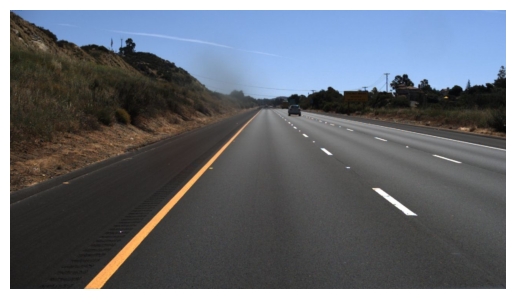

In [ ]:
# Print Image as well
if item.image is None:
    raise ValueError("Image not found or failed to load")

plt.imshow(item.image)
plt.axis('off')  # hide axes


In [ ]:
# Then format the dataset

formatter = LaneNet2Formatter(
    target_size=config['models']['lanenet2']['img_size']
)

formatted_data = formatter.batch_format(data)


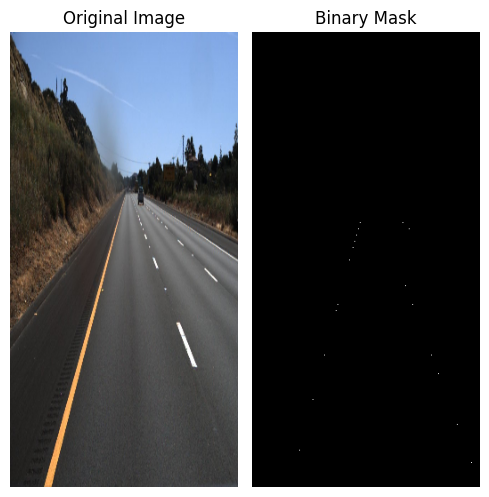

In [33]:
# Cehcking the formatted image and comapring that with the labellings

item = formatted_data[0]

# Safety check
if item.image is None:
    raise ValueError("Image not found or failed to load")

fig, axes = plt.subplots(1, 2, figsize=(5, 5))

axes[0].imshow(item.image)
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(item.binary_mask, cmap='gray')
axes[1].set_title("Binary Mask")
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Processing Part where we do the Inference